In [ ]:
from pathlib import Path
from itertools import product
import pandas as pd

from overlapsim.data import SimulationData
from overlapsim.simulation import run_simulation
from overlapsim.metrics import summarise_results
from overlapsim.plot_utils import apply_gray_style


# Project root and results directory
project_root = Path.cwd()
results_dir = project_root / "results"

# Running a single simulation

In [42]:
# Initialise the simulation data class
gen = SimulationData(
    n_samples=500,
    overlap_coef=1,
    treatment_prevalence=0.1,
    heterogeneity_coef=0.5
)

In [45]:
# Replicate the simulation 1000 times.
results = run_simulation(gen, n_replications=10000, base_seed=20002)

I save the ATE and CATE RMSE for each replication.

In [47]:
results

,ate_true,ate_hat,ate_bias,cate_rmse,treatment_rate,replication,n_samples,overlap_coef,treatment_prevalence,heterogeneity_coef
0,1.026907,0.254945,-0.771961,1.884497,0.082,0,500,1,0.1,0.5
1,1.025582,0.719172,-0.306410,0.382334,0.112,1,500,1,0.1,0.5
2,0.984427,0.754341,-0.230086,0.879804,0.110,2,500,1,0.1,0.5
3,0.973273,0.601123,-0.372149,1.154190,0.086,3,500,1,0.1,0.5
4,0.990286,0.396024,-0.594262,1.523685,0.082,4,500,1,0.1,0.5
...,...,...,...,...,...,...,...,...,...,...
9995,1.029537,0.508180,-0.521357,1.433063,0.114,9995,500,1,0.1,0.5
9996,1.018880,0.414746,-0.604134,1.716851,0.090,9996,500,1,0.1,0.5
9997,0.964006,0.759037,-0.204969,0.669679,0.130,9997,500,1,0.1,0.5
9998,1.041392,1.076434,0.035042,0.723198,0.076,9998,500,1,0.1,0.5


In [46]:
summary = summarise_results(results)
print(summary)

mean_ate_bias          -0.563325
rmse_ate               37.553502
mean_cate_rmse          3.294408
sd_ate_hat             37.551361
mean_treatment_rate     0.099836
dtype: float64


# Running all simulations

In [ ]:
heterogeneity_vals = [0, 0.5, 1, 2] # degree of heterogeneity
overlap_vals = [1, 3]   # degree of overlap
treatment_prev_vals = [0.1, 0.4]    # treatment prevalence
n_sample_vals = [300, 500, 1000, 2000]  # number of samples

all_results = []

# Run a simulation once for every combination in grid
for i, (heterogeneity_coef, overlap_coef, treatment_prevalence, n_samples) in enumerate(
    product(heterogeneity_vals, overlap_vals, treatment_prev_vals, n_sample_vals)
):
    # Display the simulation being run to keep track of where the loop is at
    print(
        f"[{i+1}/64] "
        f"heterogeneity={heterogeneity_coef}, "
        f"overlap={overlap_coef}, "
        f"treatment_prevalence={treatment_prevalence}, "
        f"n_samples={n_samples}"
    )

    # Initialise the data generating process with selected parameters
    gen = SimulationData(
        n_samples=n_samples,
        overlap_coef=overlap_coef,
        treatment_prevalence=treatment_prevalence,
        heterogeneity_coef=heterogeneity_coef,
    )

    # Replicate 1000 times per simulation
    results = run_simulation(
        generator=gen,
        n_replications=1000,
        base_seed=123 + 10000 * i,  # vary the base seed over simulations
    )

    # Append results over each loop to a single list
    all_results.append(results)

# Concatenate the results to a master dataset
full_results = pd.concat(all_results, ignore_index=True)

# Save the master dataset
full_results.to_csv(results_dir / "simulation_replication_results.csv", index=False)

full_results

[1/64] heterogeneity=0, overlap=1, treatment_prevalence=0.1, n_samples=300
[2/64] heterogeneity=0, overlap=1, treatment_prevalence=0.1, n_samples=500
[3/64] heterogeneity=0, overlap=1, treatment_prevalence=0.1, n_samples=1000
[4/64] heterogeneity=0, overlap=1, treatment_prevalence=0.1, n_samples=2000
[5/64] heterogeneity=0, overlap=1, treatment_prevalence=0.4, n_samples=300
[6/64] heterogeneity=0, overlap=1, treatment_prevalence=0.4, n_samples=500
[7/64] heterogeneity=0, overlap=1, treatment_prevalence=0.4, n_samples=1000
[8/64] heterogeneity=0, overlap=1, treatment_prevalence=0.4, n_samples=2000
[9/64] heterogeneity=0, overlap=3, treatment_prevalence=0.1, n_samples=300
[10/64] heterogeneity=0, overlap=3, treatment_prevalence=0.1, n_samples=500
[11/64] heterogeneity=0, overlap=3, treatment_prevalence=0.1, n_samples=1000
[12/64] heterogeneity=0, overlap=3, treatment_prevalence=0.1, n_samples=2000
[13/64] heterogeneity=0, overlap=3, treatment_prevalence=0.4, n_samples=300
[14/64] heterog

,ate_true,ate_hat,ate_bias,cate_rmse,treatment_rate,replication,n_samples,overlap_coef,treatment_prevalence,heterogeneity_coef
0,1.000000,0.323812,-0.676188,1.554708,0.090000,0,300,1,0.1,0.0
1,1.000000,0.681087,-0.318913,1.019739,0.126667,1,300,1,0.1,0.0
2,1.000000,1.116470,0.116470,0.990681,0.116667,2,300,1,0.1,0.0
3,1.000000,1.525379,0.525379,0.930370,0.093333,3,300,1,0.1,0.0
4,1.000000,1.858907,0.858907,1.928639,0.100000,4,300,1,0.1,0.0
...,...,...,...,...,...,...,...,...,...,...
63995,1.026843,1.669411,0.642568,0.798865,0.384500,995,2000,3,0.4,2.0
63996,0.989498,1.086480,0.096982,0.409114,0.384000,996,2000,3,0.4,2.0
63997,0.991734,0.780258,-0.211477,0.663217,0.400500,997,2000,3,0.4,2.0
63998,1.003455,0.670265,-0.333189,1.034117,0.402000,998,2000,3,0.4,2.0


In [18]:
# Apply the summary function to the dataset for each parameter combination
# Will create one row per parameter combination as a DataFrame
summary_table = (
    full_results
    .groupby(
        ["heterogeneity_coef", "overlap_coef", "treatment_prevalence", "n_samples"]
    )
    .apply(summarise_results)
    .reset_index()
)

# Save the summary table dataset
summary_table.to_csv(results_dir / "simulation_summary_results.csv", index=False)

summary_table

,heterogeneity_coef,overlap_coef,treatment_prevalence,n_samples,mean_ate_bias,rmse_ate,mean_cate_rmse,sd_ate_hat,mean_treatment_rate
0,0.0,1,0.1,300,2.617083,333.582477,120.519493,333.739122,0.100327
1,0.0,1,0.1,500,-0.014856,0.489899,0.923320,0.489919,0.099866
2,0.0,1,0.1,1000,0.000965,0.192684,0.477177,0.192778,0.099363
3,0.0,1,0.1,2000,0.004052,0.115333,0.289987,0.115320,0.099737
4,0.0,1,0.4,300,-0.003584,0.158375,0.427322,0.158414,0.400893
...,...,...,...,...,...,...,...,...,...
59,2.0,3,0.1,2000,-1.353728,18.839656,7.195589,18.801119,0.099911
60,2.0,3,0.4,300,-0.456699,4.491836,3.795894,4.469754,0.399863
61,2.0,3,0.4,500,-0.350776,3.943728,2.550314,3.929267,0.399788
62,2.0,3,0.4,1000,-0.111568,1.157280,1.422709,1.151715,0.400013


In [115]:
# Searching the table for a specific set of simulations
summary_table.loc[
    (summary_table["overlap_coef"] == 3) &
    (summary_table["treatment_prevalence"] == 0.4) &
    (summary_table["n_samples"] == 1000)
]

,heterogeneity_coef,overlap_coef,treatment_prevalence,n_samples,mean_ate_bias,rmse_ate,mean_cate_rmse,sd_ate_hat,mean_treatment_rate
14,0.0,3,0.4,1000,-0.006599,0.396016,0.585291,0.396159,0.399758
30,0.5,3,0.4,1000,-0.033129,0.545089,0.703677,0.543288,0.399547
46,1.0,3,0.4,1000,-0.089845,0.723276,0.963303,0.718605,0.400202
62,2.0,3,0.4,1000,-0.111568,1.157280,1.422709,1.151715,0.400013


# Creating Figures

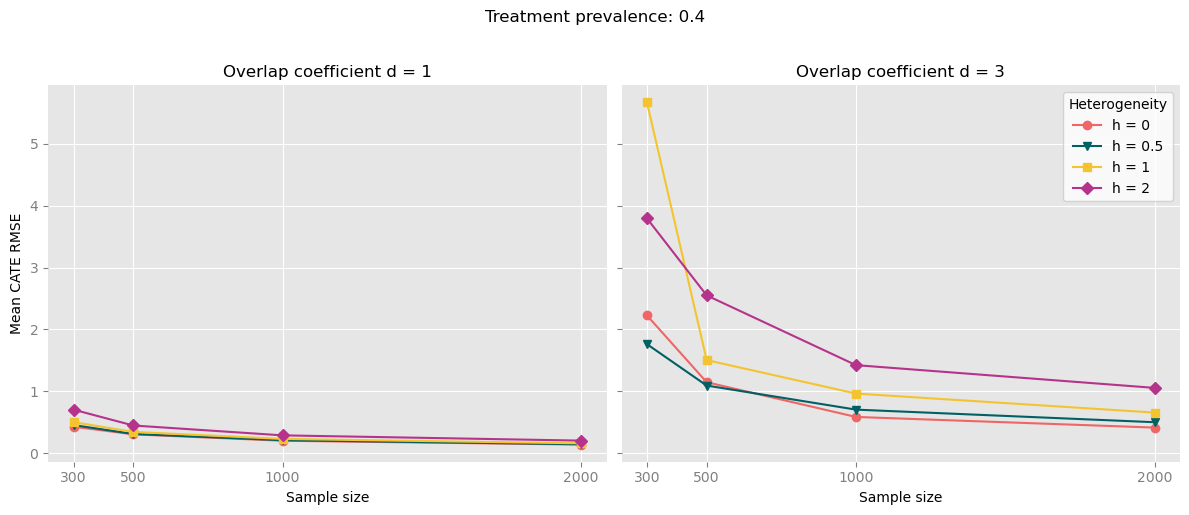

In [108]:
import matplotlib.pyplot as plt
import pandas as pd

# Keep only treatment prevalence = 0.4
plot_data = summary_table[summary_table["treatment_prevalence"] == 0.4].copy()

# Sort for clean plotting
plot_data = plot_data.sort_values(
    by=["overlap_coef", "heterogeneity_coef", "n_samples"]
)

heterogeneity_vals = [0, 0.5, 1, 2]
overlap_vals = [1, 3]
colours = ['#EE6666', '#016064', "#F4C430", "#B5338A"]
markers = ["o", "v", "s", "D"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, overlap in zip(axes, overlap_vals):
    panel_data = plot_data[plot_data["overlap_coef"] == overlap]

    for h, colour, marker in zip(heterogeneity_vals, colours, markers):
        line_data = panel_data[panel_data["heterogeneity_coef"] == h].sort_values("n_samples")

        ax.plot(
            line_data["n_samples"],
            line_data["mean_cate_rmse"],
            marker=marker,
            color=colour,
            label=f"h = {h}"
        )

    ax.set_title(f"Overlap coefficient d = {overlap}")
    ax.set_xlabel("Sample size")
    ax.set_xticks(sorted(panel_data["n_samples"].unique()))
    apply_gray_style(ax)

axes[0].set_ylabel("Mean CATE RMSE")
axes[1].legend(title="Heterogeneity")

fig.suptitle("Treatment prevalence: 0.4", y=1.02)
plt.tight_layout()
plt.show()

We can clearly see that greater heterogeneity in the treatment effect leads to higher RMSE. This effect is amplified when overlap is poor, leading to higher RMSE even as sample size grows; however, in general, a larger sample size causes the RMSE to converge to zero regardless of the degree of heterogeneity.

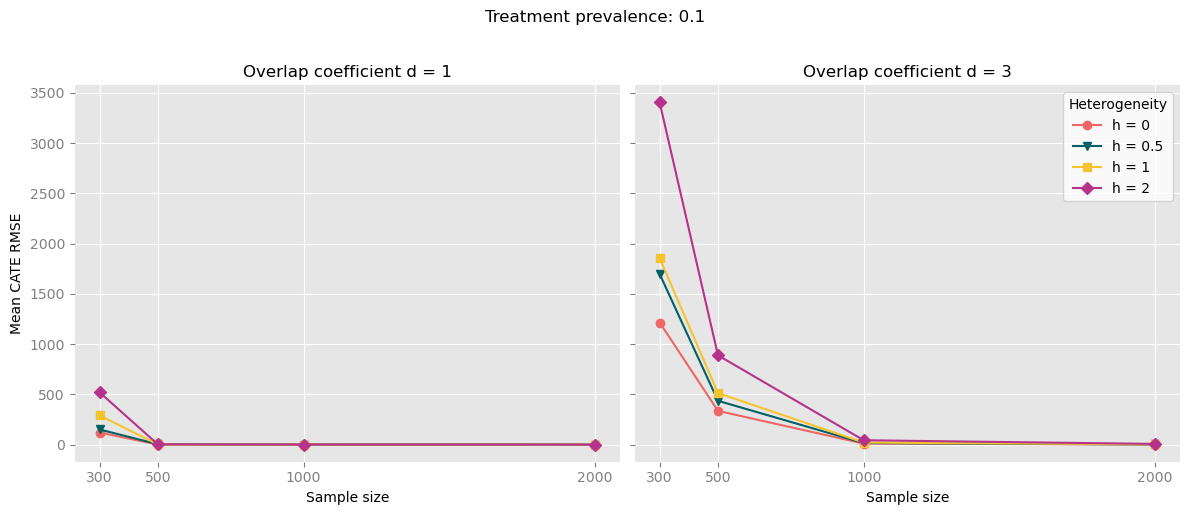

In [109]:
import matplotlib.pyplot as plt
import pandas as pd

# Keep only treatment prevalence = 0.1
plot_data = summary_table[summary_table["treatment_prevalence"] == 0.1].copy()

# Sort for clean plotting
plot_data = plot_data.sort_values(
    by=["overlap_coef", "heterogeneity_coef", "n_samples"]
)

heterogeneity_vals = [0, 0.5, 1, 2]
overlap_vals = [1, 3]
colours = ['#EE6666', '#016064', "#F4C430", "#B5338A"]
markers = ["o", "v", "s", "D"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, overlap in zip(axes, overlap_vals):
    panel_data = plot_data[plot_data["overlap_coef"] == overlap]

    for h, colour, marker in zip(heterogeneity_vals, colours, markers):
        line_data = panel_data[panel_data["heterogeneity_coef"] == h].sort_values("n_samples")

        ax.plot(
            line_data["n_samples"],
            line_data["mean_cate_rmse"],
            marker=marker,
            color=colour,
            label=f"h = {h}"
        )

    ax.set_title(f"Overlap coefficient d = {overlap}")
    ax.set_xlabel("Sample size")
    ax.set_xticks(sorted(panel_data["n_samples"].unique()))
    apply_gray_style(ax)

axes[0].set_ylabel("Mean CATE RMSE")
axes[1].legend(title="Heterogeneity")

fig.suptitle("Treatment prevalence: 0.1", y=1.02)
plt.tight_layout()
plt.show()

When treatment prevalence is rare, we see that the RMSE can be very high. In small samples, this leads to a high RMSE even when there is overlap. The right hand side panel shows almost complete failure of the overlap assumption. In small samples, the model cannot identify the CATE and RMSE is high. THis is a major issue when the degree of heterogeneity is strong. However, as sample size grows large, there is more identifying variation and more potential overlap (due to having more observations). This leads to improvement, although (as seen in the `summary` table) the RMSE remains very high.

This is a warning against using doubly robust methods when we suspect heterogeneous treatment effects and sample size is small. Heterogeneity amplifies the finite sample bias beyond that of a homogeneous treatment. This is particularly pronounced when the treatment prevalence is also low, so overlap in the sample is even worse.

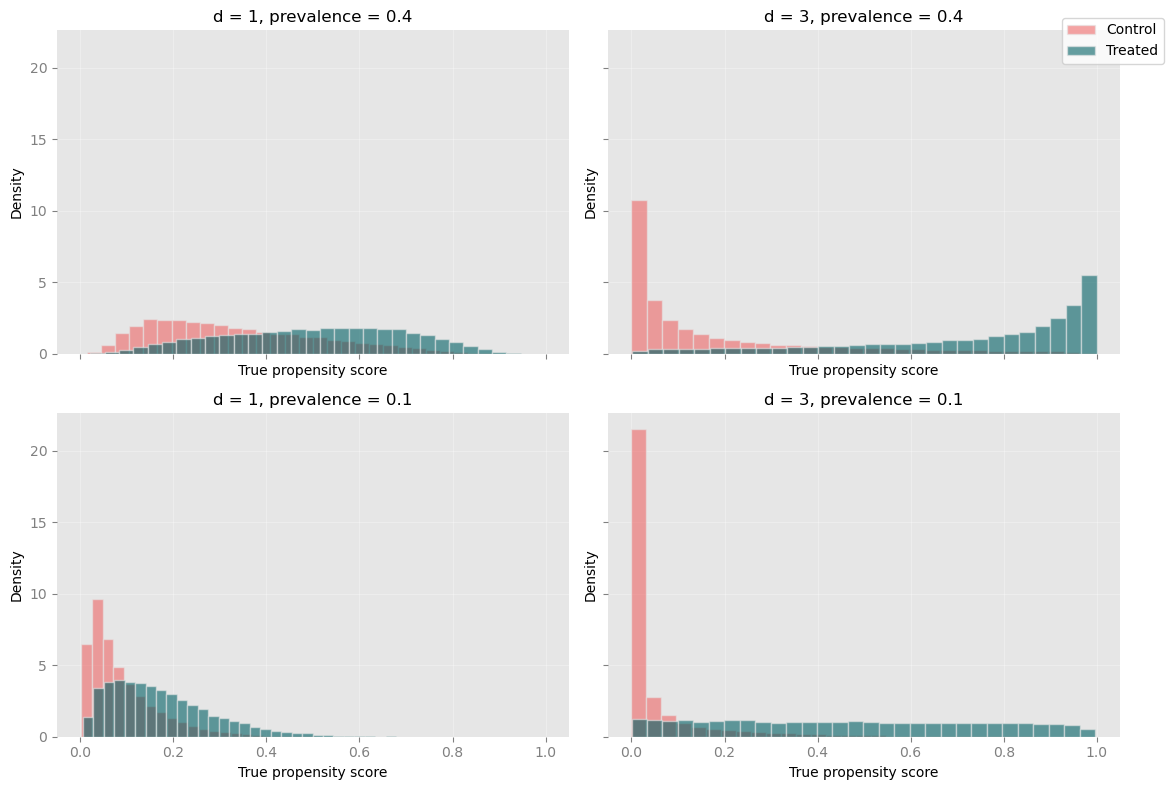

In [112]:
import matplotlib.pyplot as plt
import numpy as np

scenarios = [
    {"overlap_coef": 1, "treatment_prevalence": 0.4},
    {"overlap_coef": 3, "treatment_prevalence": 0.4},
    {"overlap_coef": 1, "treatment_prevalence": 0.1},
    {"overlap_coef": 3, "treatment_prevalence": 0.1},
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, sc in zip(axes, scenarios):
    gen = SimulationData(
        n_samples=100000,
        overlap_coef=sc["overlap_coef"],
        treatment_prevalence=sc["treatment_prevalence"],
        heterogeneity_coef=0,  # irrelevant for propensity
    )
    
    data = gen.generate(random_state=123)
    propensity = data["propensity"]
    T = data["T"]

    # Split propensity scores by observed treatment group
    prop_treated = propensity[T == 1]
    prop_control = propensity[T == 0]

    ax.hist(
        prop_control,
        bins=30,
        density=True,
        alpha=0.6,
        edgecolor='#E6E6E6',
        color='#EE6666',
        label="Control",
    )
    ax.hist(
        prop_treated,
        bins=30,
        density=True,
        alpha=0.6,
        edgecolor='#E6E6E6',
        color='#016064',
        label="Treated",
    )

    ax.set_title(
        f"d = {sc['overlap_coef']}, prevalence = {sc['treatment_prevalence']}"
    )
    ax.set_xlabel("True propensity score")
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.3)
    apply_gray_style(ax)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.98, 0.98))

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()

This shows the four overlap treatments. The top-right panel corresponds to the best overlap, when treatment prevalence is high and overlap is good. 